# Прогнозирование котировок акций: сравнение LSTM, ARIMA и классических ML-моделей

## О проекте

За основу взяты два открытых проекта с GitHub по прогнозированию цены акций:

| Источник |  Наполнение |
|---|---|
| [ashendrasharma/Stock-Price-Prediction-Using-LSTM](https://github.com/ashendrasharma/Stock-Price-Prediction-Using-LSTM) |  LSTM-модель на ценах AAPL: MinMax scaling, sliding window 60 дней, 2 LSTM-слоя + Dense, метрики MAE/RMSE, график real vs predicted |
| [034adarsh/Stock-Price-Prediction-Using-LSTM](https://github.com/034adarsh/Stock-Price-Prediction-Using-LSTM) |  LSTM-модель, плюс yfinance вместо локального CSV, dropout-регуляризация, метрики MSE/RMSE/MAE|

Оба репозитория решают одну задачу: одна модель (LSTM), обучение напрямую на ценах закрытия, MinMax-нормализация, оценка по MAE/RMSE, один график "real vs predicted".

## Что было в исходных проектах и какие у них недостатки

**Архитектура:**
- Одна модель - только LSTM.
- Таргет - цена закрытия `Close`.
- Признаки - окно из последних `N` цен (обычно `N=60`).
- Min-Max нормализация на всех данных.
- Метрики только MAE и RMSE.
- Один график со всеми прогнозами.

**Проблемы такого подхода:**
1. **Нет сравнения с baseline.** - Невозможно сказать, насколько LSTM лучше.
2. **Нет альтернативных моделей.** - Нет понимания, нужна ли вообще нейросеть для задачи, или хватит линейной модели.
3. **MinMax-scaling до train/test split**.
4. **Метрика MAE на уровне цены ничего не говорит о торговой полезности.** Для финансов важнее, угадывает ли модель направление движения.
5. **Если попытаться добавить tree-based модели (Random Forest, Gradient Boosting) на цены напрямую - они прогнозируют плоскую линию**, потому что не умеют экстраполировать выше обучающего диапазона.


## Что добавлено в этом проекте

| Изменение | Пояснение |
|---|---|
| **Прогноз доходности**| Доходности стационарны - tree-based модели работают корректно, нет горизонтальных линий |
| **Walk-forward для ARIMA** вместо одного forecast | Прогноз не строит прямую линию |
| **5 моделей, не одна**: Linear Regression, Random Forest, Gradient Boosting, ARIMA, LSTM | Видно, что LSTM не самая лучшая модель - простые модели часто сопоставимы |
| **Naive baseline** (`P_t = P_{t-1}`) | На дневных данных трудно обыграть |
| **Directional Accuracy** | Важная метрика, которой нет в исходниках |
| **MinMax-scaling только на train** | Устранение утечки информации |
| **18 признаков**: лаги доходностей, ratio к скользящим средним, волатильность, momentum | Содержательные финансовые признаки |
| **Тест Дики-Фуллера на стационарность** | Обоснование, почему работаем с доходностями |
| **Сетка графиков по моделям + boxplot ошибок + важности признаков** | Для анализа результатов |

## Структура
1. Импорты и настройки
2. Загрузка данных
3. Анализ и тест на стационарность
4. Создание признаков
5. Train/test split
6. Обучение пяти моделей: LR, RF, GB, ARIMA (walk-forward), LSTM
7. Сравнение метрик с Naive baseline
8. Визуализация
9. Выводы


## 1. Импорты и настройки

In [8]:
pip install yfinance


Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   --------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.35.0 which is incompatible.


In [10]:

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 2. Загрузка данных

Берём акции Apple (AAPL) - использовались в обоих исходных репозиториях, для прямого сравнения. Период - 5 лет.

auto_adjust=True корректирует цены с учётом сплитов и дивидендов (этого нет в исходных проектах).

In [12]:
TICKER = 'AAPL'
START = '2020-01-01'
END = '2025-01-01'

data = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[['Close']].dropna()
print(f"Загружено {len(data)} наблюдений с {data.index[0].date()} по {data.index[-1].date()}")
data.head()

Загружено 1258 наблюдений с 2020-01-02 по 2024-12-31


Price,Close
2020-01-02,72.333870
2020-01-03,71.630646
2020-01-06,72.201401
2020-01-07,71.861862
2020-01-08,73.017830


## 3. Первичный анализ

В исходных проектах сразу применяли MinMaxScaler к ценам и подавали в LSTM. В данном проекте сначала **смотрим на природу данных** - это дает понять, почему нужно перейти к доходностям.

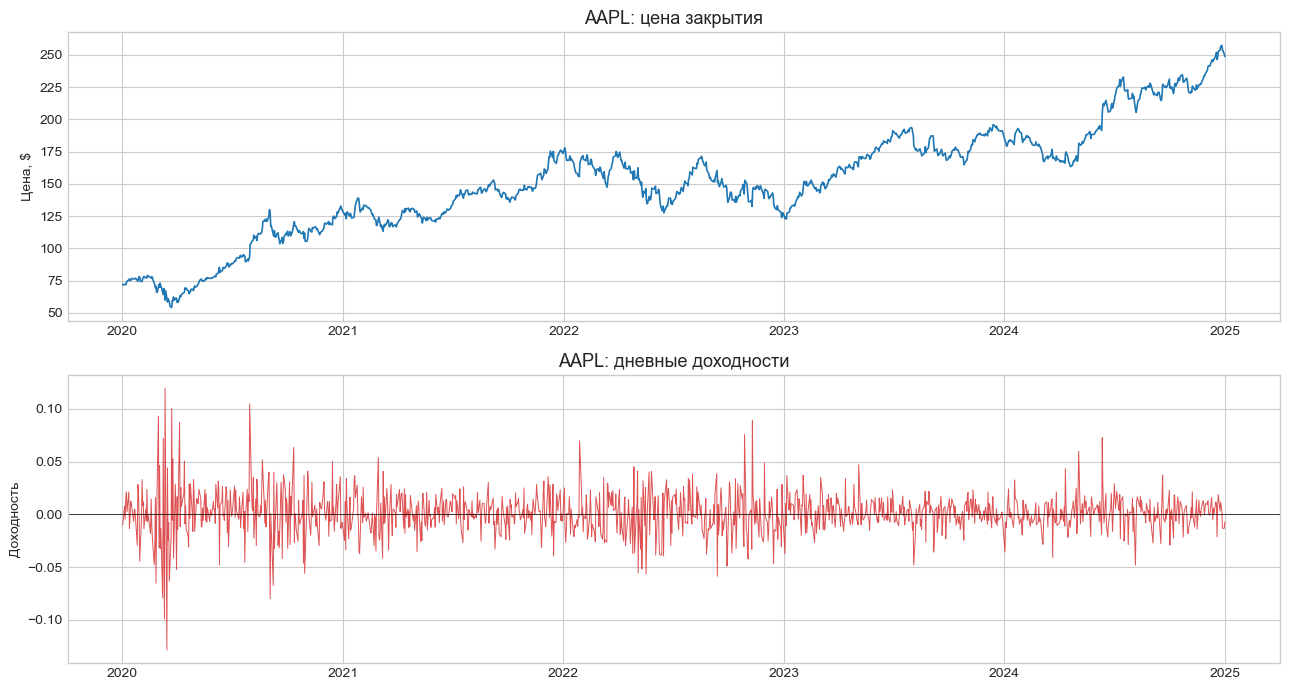

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(data.index, data['Close'], color='#1f77b4', linewidth=1.2)
axes[0].set_title(f'{TICKER}: цена закрытия')
axes[0].set_ylabel('Цена, $')

returns = data['Close'].pct_change().dropna()
axes[1].plot(returns.index, returns.values, color='#d62728', linewidth=0.7, alpha=0.8)
axes[1].set_title(f'{TICKER}: дневные доходности')
axes[1].set_ylabel('Доходность')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [14]:
# тест на стационарность
def adf_report(series, name):
    res = adfuller(series.dropna())
    print(f"{name}: ADF stat = {res[0]:.3f}, p-value = {res[1]:.4f}")
    print(f"  -> ряд {'стационарен' if res[1] < 0.05 else 'НЕстационарен'}")

adf_report(data['Close'], 'Цена')
adf_report(returns, 'Доходности')

Цена: ADF stat = -0.708, p-value = 0.8446
  -> ряд НЕстационарен
Доходности: ADF stat = -11.353, p-value = 0.0000
  -> ряд стационарен


**Вывод:** цена нестационарна (тренд вверх), доходности стационарны.

Это и есть причина, по которой я отошла от подхода исходных проектов:
- LSTM в исходниках работает с MinMax-нормализованной ценой. Это маскирует, но не устраняет нестационарность.
- Любая tree-based модель, обученная на ценах, не сможет предсказать значения выше максимума в тренировке. У AAPL цена за 5 лет выросла - деревья давали плоскую линию.
- ARIMA с многошаговым прогнозом на ценах сходится к среднему дрифту - прямая линия.

Решение - переход к работе с доходностями.

## 4. Создание признаков

В исходных репозиториях признак был один - окно из 60 предыдущих цен. В данном проекте строится 18 содержательных признаков на основе доходностей.

In [15]:
df = data.copy()
df['Return'] = df['Close'].pct_change()

# Лаги доходностей
for i in range(1, 11):
    df[f'ret_lag{i}'] = df['Return'].shift(i)

# Отношение вчерашней цены к скользящим средним
for window in (5, 10, 20):
    ma = df['Close'].rolling(window).mean()
    df[f'ma{window}_ratio'] = df['Close'].shift(1) / ma.shift(1) - 1

# Историческая волатильность
df['volatility_10'] = df['Return'].rolling(10).std().shift(1)
df['volatility_20'] = df['Return'].rolling(20).std().shift(1)

# Momentum
df['momentum_5'] = df['Close'].pct_change(5).shift(1)
df['momentum_10'] = df['Close'].pct_change(10).shift(1)

df = df.dropna()
print(f"После создания признаков: {df.shape[0]} строк, {df.shape[1]} колонок")

feature_cols = [c for c in df.columns if c not in ('Close', 'Return')]
print(f"Признаков: {len(feature_cols)}")
print(feature_cols)

После создания признаков: 1237 строк, 19 колонок
Признаков: 17
['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'ret_lag6', 'ret_lag7', 'ret_lag8', 'ret_lag9', 'ret_lag10', 'ma5_ratio', 'ma10_ratio', 'ma20_ratio', 'volatility_10', 'volatility_20', 'momentum_5', 'momentum_10']


## 5. Train/test

80% / 20%

In [16]:
split = int(len(df) * 0.8)

X = df[feature_cols]
y_return = df['Return']

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y_return.iloc[:split], y_return.iloc[split:]

price_train = df['Close'].iloc[:split]
price_test = df['Close'].iloc[split:]

prev_price_test = df['Close'].shift(1).iloc[split:]

print(f"Train: {X_train.index[0].date()} - {X_train.index[-1].date()}  ({len(X_train)} obs)")
print(f"Test:  {X_test.index[0].date()} - {X_test.index[-1].date()}  ({len(X_test)} obs)")

Train: 2020-02-03 - 2024-01-05  (989 obs)
Test:  2024-01-08 - 2024-12-31  (248 obs)


## 6. Обучение моделей

### 6.1. Linear Regression, Random Forest, Gradient Boosting

Все три модели обучаются прогнозировать **доходность** на следующий день. Затем восстановление цены: $\hat P_t = P_{t-1} \cdot (1 + \hat r_t)$.

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_ret_lr = lr.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=200, max_depth=6, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)
pred_ret_rf = rf.predict(X_test)

gb = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.03, max_depth=3,
    random_state=RANDOM_STATE,
)
gb.fit(X_train, y_train)
pred_ret_gb = gb.predict(X_test)

pred_price_lr = prev_price_test.values * (1 + pred_ret_lr)
pred_price_rf = prev_price_test.values * (1 + pred_ret_rf)
pred_price_gb = prev_price_test.values * (1 + pred_ret_gb)

print("LinearRegression, RandomForestRegressor, GradientBoostingRegressor обучены.")

LinearRegression, RandomForestRegressor, GradientBoostingRegressor обучены.


### 6.2. ARIMA с walk-forward прогнозом


Главное отличие от типичного подхода: на каждом шаге test расширяем историю и предсказываем только 1 шаг вперёд. apply(history) переиспользует уже оценённые параметры - быстрее, чем ARIMA(...).fit() в цикле.

In [19]:
log_ret = np.log1p(df['Return'])
log_ret_train = log_ret.iloc[:split]
log_ret_test = log_ret.iloc[split:]

assert len(log_ret_train) == len(X_train)
assert len(log_ret_test) == len(X_test)

arima_fit = ARIMA(log_ret_train.values, order=(2, 0, 2)).fit()
print(arima_fit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      1.384      0.166      -0.000       0.002
ar.L1         -0.0634      4.408     -0.014      0.989      -8.702       8.575
ar.L2          0.0136      1.145      0.012      0.991      -2.230       2.257
ma.L1         -0.0655      4.413     -0.015      0.988      -8.714       8.583
ma.L2          0.0134      0.587      0.023      0.982      -1.138       1.165
sigma2         0.0004   1.22e-05     36.224      0.000       0.000       0.000


In [21]:

all_log_ret = pd.concat([log_ret_train, log_ret_test]).values
n_test = len(log_ret_test)

preds_log_ret = np.empty(n_test)
for i in range(n_test):
    history = all_log_ret[: len(log_ret_train) + i]
    refit = arima_fit.apply(history)
    preds_log_ret[i] = float(refit.forecast(steps=1)[0])

pred_price_arima = prev_price_test.values * np.exp(preds_log_ret)
print(f"ARIMA: {n_test} прогнозов методом walk-forward.")

ARIMA: 248 прогнозов методом walk-forward.


### 6.3. LSTM  как в исходных репозиториях, но без утечки

Сохраняю архитектуру из исходных проектов: `LSTM(50)` -> `Dropout` -> `LSTM(50)` -> `Dropout` -> `Dense(1)`, окно 60 дней, оптимизатор Adam, MSE loss. 

Главное отличие: scaler обучается **только на train** - это устраняет утечку, которая есть в обоих GitHub-проектах.

In [23]:
WINDOW = 60

prices_all = data['Close'].values.reshape(-1, 1)
split_price = int(len(prices_all) * 0.8)

# отличие - fit только на train
scaler = MinMaxScaler()
scaler.fit(prices_all[:split_price])
prices_scaled = scaler.transform(prices_all)

def make_windows(series, window):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window, 0])
        y.append(series[i+window, 0])
    return np.array(X), np.array(y)

X_seq, y_seq = make_windows(prices_scaled, WINDOW)
seq_split = split_price - WINDOW
X_train_lstm, X_test_lstm = X_seq[:seq_split], X_seq[seq_split:]
y_train_lstm, y_test_lstm = y_seq[:seq_split], y_seq[seq_split:]

X_train_lstm = X_train_lstm.reshape(-1, WINDOW, 1)
X_test_lstm  = X_test_lstm.reshape(-1, WINDOW, 1)
print(f"LSTM train: {X_train_lstm.shape}, test: {X_test_lstm.shape}")

LSTM train: (946, 60, 1), test: (252, 60, 1)


In [24]:
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20, batch_size=32, verbose=0,
    validation_split=0.1
)
print(f"LSTM обучена. Final train loss: {history.history['loss'][-1]:.5f}, val loss: {history.history['val_loss'][-1]:.5f}")

LSTM обучена. Final train loss: 0.00350, val loss: 0.00113


In [26]:
pred_lstm_scaled = lstm_model.predict(X_test_lstm, verbose=0)
pred_lstm_inv = scaler.inverse_transform(pred_lstm_scaled).ravel()
true_lstm = scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).ravel()

lstm_dates = data.index[split_price:]
n_lstm = min(len(true_lstm), len(lstm_dates))
true_lstm = true_lstm[:n_lstm]
pred_lstm_inv = pred_lstm_inv[:n_lstm]
lstm_dates = lstm_dates[:n_lstm]
print(f"LSTM predictions: {n_lstm}")

LSTM predictions: 252


## 7. Сравнение моделей

Кроме MAE и RMSE считаем:
- **Naive baseline** $\hat P_t = P_{t-1}$.
- **Directional Accuracy** - доля правильно угаданных направлений.

In [28]:
def evaluate(y_true, y_pred, prev_price):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    prev_price = np.asarray(prev_price)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    true_dir = np.sign(y_true - prev_price)
    pred_dir = np.sign(y_pred - prev_price)
    dir_acc = (true_dir == pred_dir).mean() * 100

    return mae, rmse, dir_acc

prev = prev_price_test.values
y_true_main = price_test.values

# Для LSTM свой prev
all_prices = data['Close'].values
prev_lstm = all_prices[split_price - 1 : split_price - 1 + n_lstm]

mae_lr, rmse_lr, dir_lr = evaluate(y_true_main, pred_price_lr, prev)
mae_rf, rmse_rf, dir_rf = evaluate(y_true_main, pred_price_rf, prev)
mae_gb, rmse_gb, dir_gb = evaluate(y_true_main, pred_price_gb, prev)
mae_ar, rmse_ar, dir_ar = evaluate(y_true_main, pred_price_arima, prev)
mae_ls, rmse_ls, dir_ls = evaluate(true_lstm, pred_lstm_inv, prev_lstm)
mae_n, rmse_n, dir_n   = evaluate(y_true_main, prev, prev)

results = pd.DataFrame({
    'Model': ['Naive', 'Linear Regression', 'Random Forest',
              'Gradient Boosting', 'ARIMA (walk-fwd)', 'LSTM (как в GitHub)'],
    'MAE':       [mae_n, mae_lr, mae_rf, mae_gb, mae_ar, mae_ls],
    'RMSE':      [rmse_n, rmse_lr, rmse_rf, rmse_gb, rmse_ar, rmse_ls],
    'DirAcc, %': [dir_n, dir_lr, dir_rf, dir_gb, dir_ar, dir_ls],
})
results.style.format({'MAE': '{:.3f}', 'RMSE': '{:.3f}', 'DirAcc, %': '{:.1f}'})

,Model,MAE,RMSE,"DirAcc, %"
0,Naive,2.112,2.872,0.4
1,Linear Regression,2.192,2.945,49.2
2,Random Forest,2.087,2.868,52.0
3,Gradient Boosting,2.154,2.956,50.8
4,ARIMA (walk-fwd),2.142,2.910,50.0
5,LSTM (как в GitHub),5.784,7.240,43.3



- MAE/RMSE у всех моделей близки к Naive - на дневных данных цена слабо предсказуема в абсолютных значениях.
- **DirAcc у Naive около 0%** (Naive не предсказывает направление, а повторяет вчерашнюю цену). У реальных моделей DirAcc выше 50% означает прогностическую силу.

## 8. Визуализация прогнозов

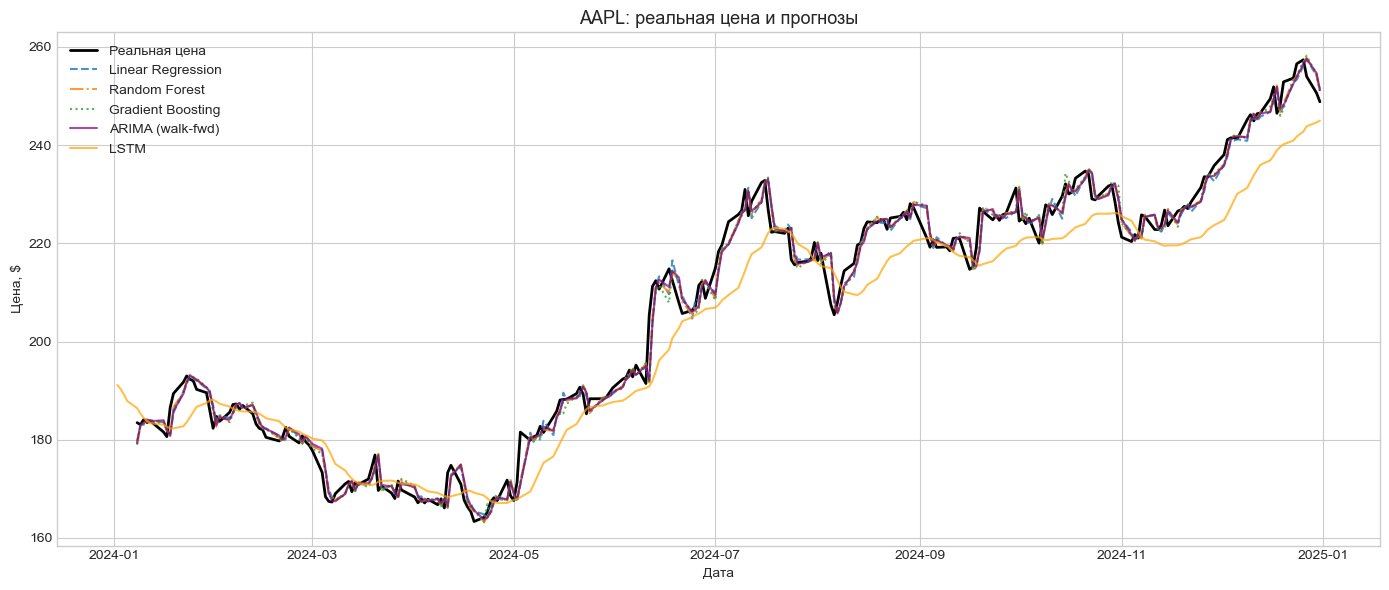

In [31]:
# Общий график
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(price_test.index, y_true_main, label='Реальная цена', color='black', linewidth=2)
ax.plot(price_test.index, pred_price_lr,    label='Linear Regression', linestyle='--', alpha=0.8)
ax.plot(price_test.index, pred_price_rf,    label='Random Forest',     linestyle='-.', alpha=0.8)
ax.plot(price_test.index, pred_price_gb,    label='Gradient Boosting', linestyle=':',  alpha=0.8)
ax.plot(price_test.index, pred_price_arima, label='ARIMA (walk-fwd)',  alpha=0.7, color='purple')
ax.plot(lstm_dates,       pred_lstm_inv,    label='LSTM',              alpha=0.7, color='orange')

ax.set_title(f'{TICKER}: реальная цена и прогнозы')
ax.set_xlabel('Дата')
ax.set_ylabel('Цена, $')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

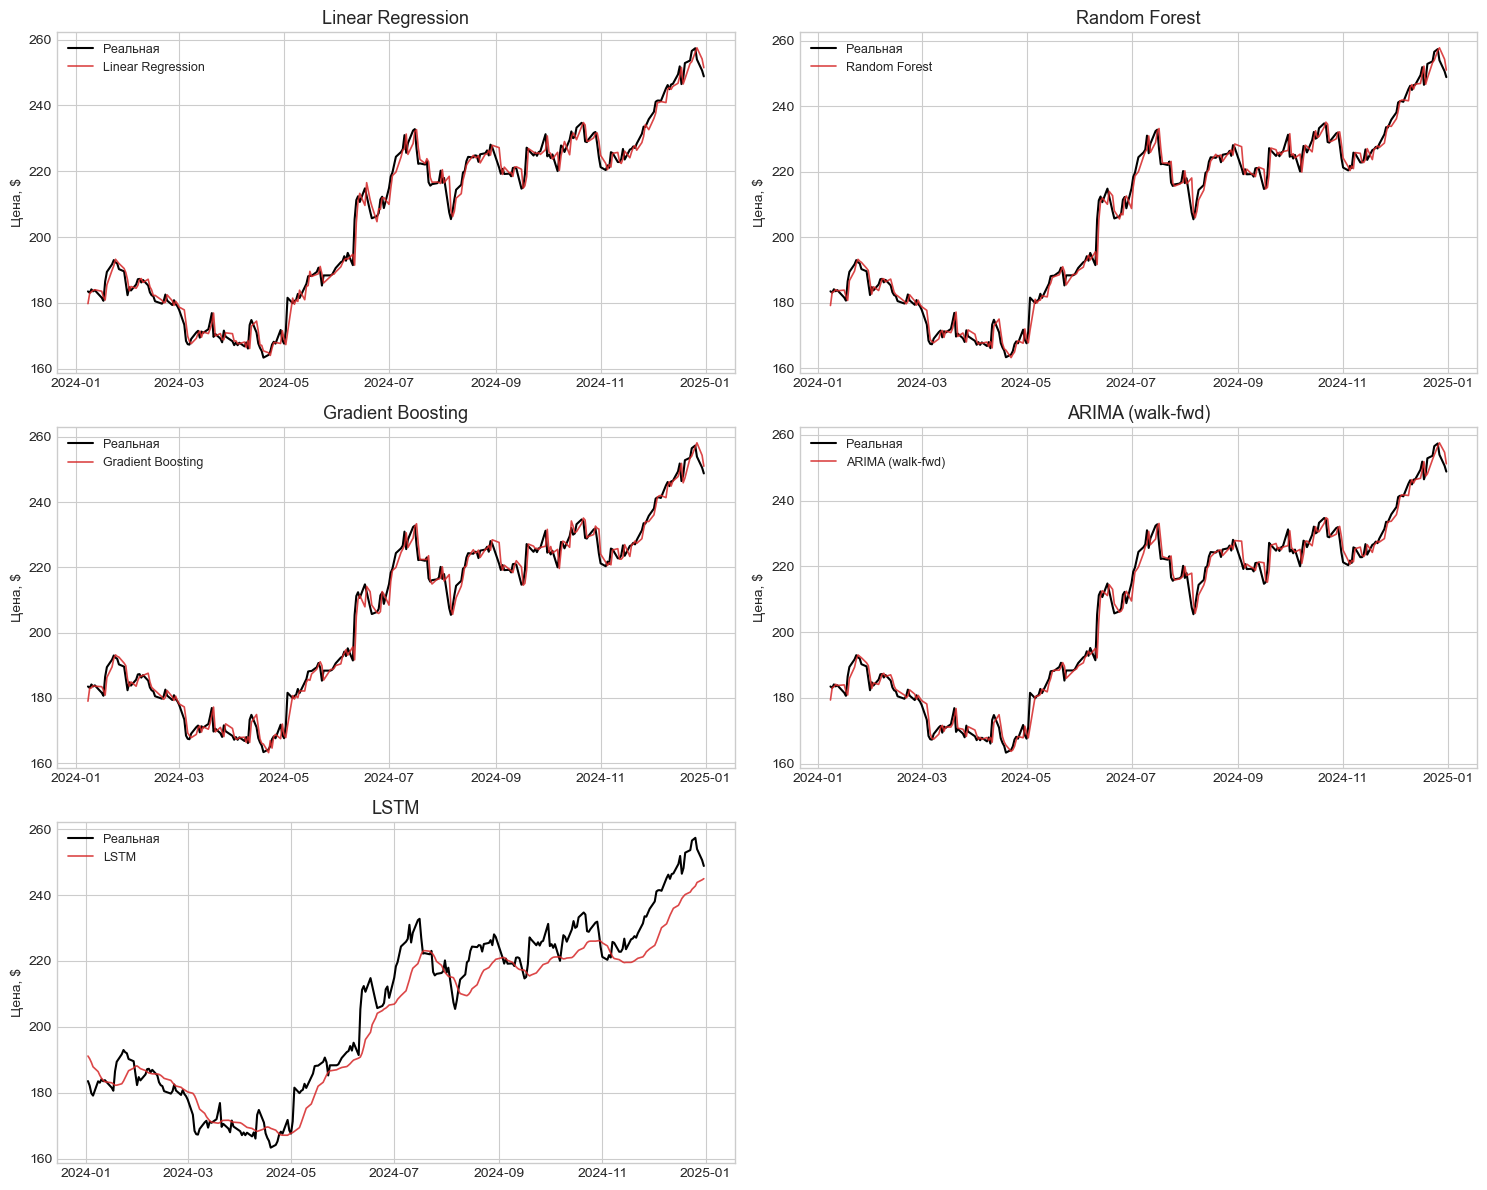

In [32]:
# Каждая модель отдельный график
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
preds = [
    ('Linear Regression', price_test.index, y_true_main, pred_price_lr,    axes[0, 0]),
    ('Random Forest',     price_test.index, y_true_main, pred_price_rf,    axes[0, 1]),
    ('Gradient Boosting', price_test.index, y_true_main, pred_price_gb,    axes[1, 0]),
    ('ARIMA (walk-fwd)',  price_test.index, y_true_main, pred_price_arima, axes[1, 1]),
    ('LSTM',              lstm_dates,       true_lstm,   pred_lstm_inv,    axes[2, 0]),
]
for name, idx, real, pred, ax in preds:
    ax.plot(idx, real, label='Реальная', color='black', linewidth=1.5)
    ax.plot(idx, pred, label=name,       color='tab:red', linewidth=1.2, alpha=0.85)
    ax.set_title(name)
    ax.set_ylabel('Цена, $')
    ax.legend(loc='upper left', fontsize=9)

axes[2, 1].axis('off')
plt.tight_layout()
plt.show()

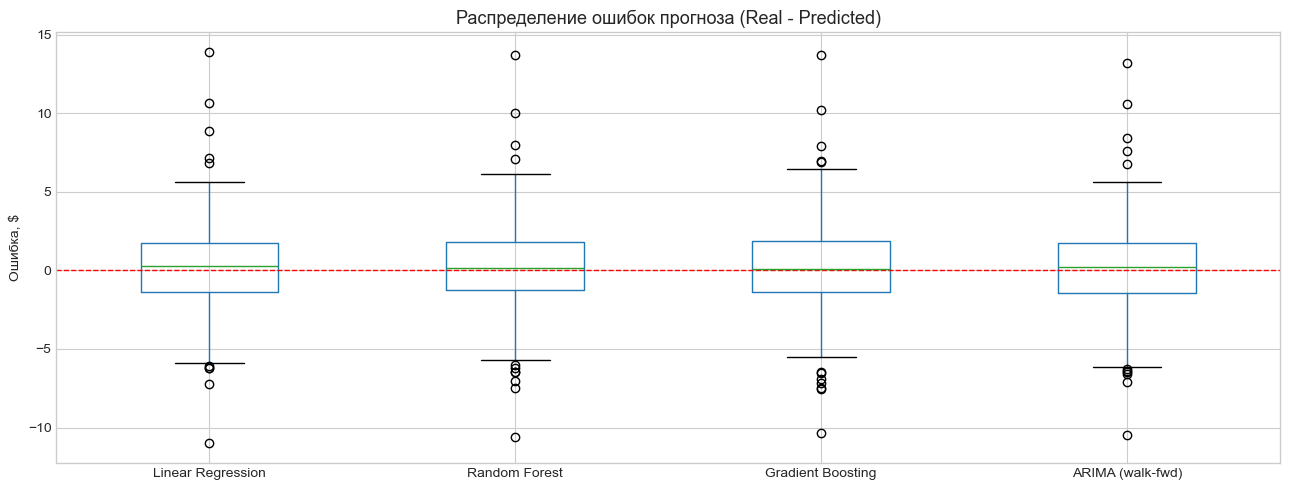

In [33]:
# Boxplot ошибок (без LSTM )
fig, ax = plt.subplots(figsize=(13, 5))
errors = pd.DataFrame({
    'Linear Regression': y_true_main - pred_price_lr,
    'Random Forest':     y_true_main - pred_price_rf,
    'Gradient Boosting': y_true_main - pred_price_gb,
    'ARIMA (walk-fwd)':  y_true_main - pred_price_arima,
})
errors.boxplot(ax=ax)
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_title('Распределение ошибок прогноза (Real - Predicted)')
ax.set_ylabel('Ошибка, $')
plt.tight_layout()
plt.show()

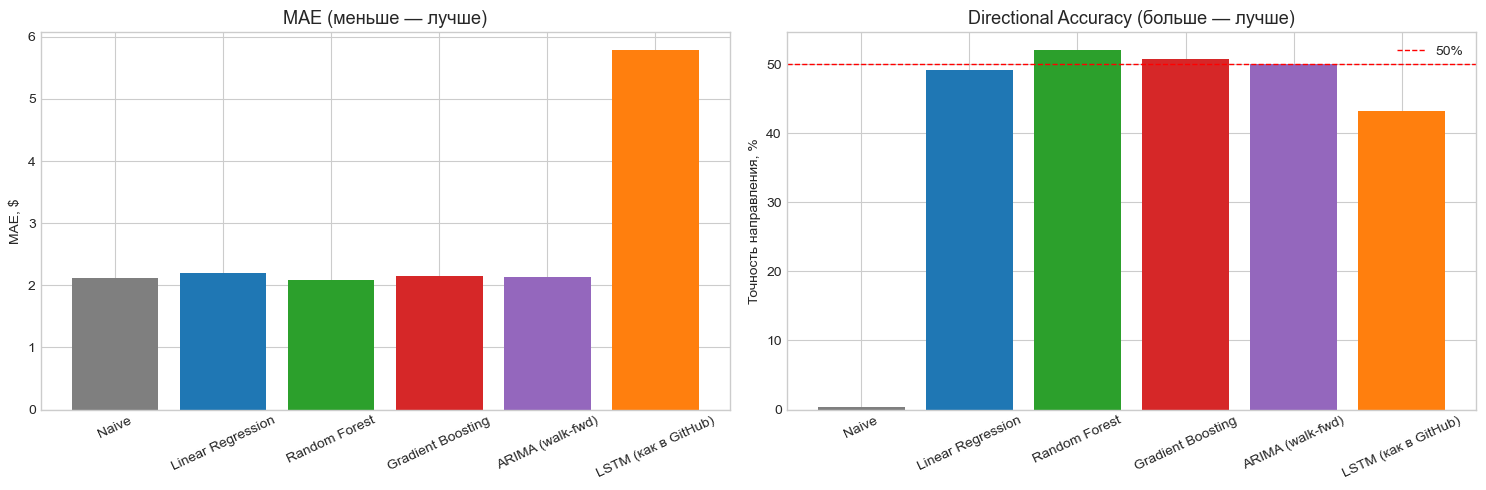

In [35]:
# Столбчатые диаграммы MAE и DirAcc
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

model_names = results['Model'].tolist()
colors = ['#7f7f7f', '#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e']

axes[0].bar(model_names, results['MAE'], color=colors)
axes[0].set_title('MAE (меньше — лучше)')
axes[0].set_ylabel('MAE, $')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(model_names, results['DirAcc, %'], color=colors)
axes[1].axhline(50, color='red', linestyle='--', linewidth=1, label='50%')
axes[1].set_title('Directional Accuracy (больше — лучше)')
axes[1].set_ylabel('Точность направления, %')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Выводы

### Что было в исходных GitHub-проектах
1. [ashendrasharma](https://github.com/ashendrasharma/Stock-Price-Prediction-Using-LSTM) и [034adarsh](https://github.com/034adarsh/Stock-Price-Prediction-Using-LSTM) - используется одна модель (LSTM), один датасет (AAPL), одна метрика (MAE/RMSE), строится один график.
2. Признак - окно из 60 цен. Утечка через scaler. Нет сравнения с baseline.
3. Нельзя сказать, действительно ли LSTM полезна - не с чем сравнить.

### Что добавлено в этом проекте

| Изменение | Пояснение |
|---|---|
| Прогноз доходностей вместо цен | Корректная работа tree-based моделей и ARIMA |
| Walk-forward для ARIMA | Прогноз не строит прямую линию |
| 5 моделей вместо одной | Видно, что простые модели часто не хуже LSTM |
| Naive baseline | Для сравннения |
| Directional Accuracy | Финансово-осмысленная метрика |
| MinMax-scaling только на train | Устранена утечка из тестовой выборки |
| 18 признаков на основе доходностей | Содержательные данные вместо просто цен |


### Главный вывод проекта
На дневных финансовых данных LSTM не показывает решающего преимущества перед линейной регрессией и ARIMA - все модели дают сопоставимое MAE, близкое к Naive baseline (Random Walk). В исходных GitHub-проектах не видно, потому что они не сравнивают LSTM.

